### Importação dos dados



In [33]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_1.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_4.csv"

loja = pd.read_csv(url)
loja2 = pd.read_csv(url2)
loja3 = pd.read_csv(url3)
loja4 = pd.read_csv(url4)

loja.head()

,Produto,Categoria do Produto,Preço,Frete,Data da Compra,Vendedor,Local da compra,Avaliação da compra,Tipo de pagamento,Quantidade de parcelas,lat,lon
0,Assistente virtual,eletronicos,219.08,9.249790,16/01/2021,Pedro Gomes,SP,4,cartao_credito,8,-22.19,-48.79
1,Mesa de jantar,moveis,256.35,11.234305,18/05/2022,Beatriz Moraes,RJ,1,cartao_credito,4,-22.25,-42.66
2,Jogo de tabuleiro,brinquedos,279.51,21.262681,15/03/2021,João Souza,DF,1,cartao_credito,1,-15.83,-47.86
3,Micro-ondas,eletrodomesticos,1009.99,54.667344,03/05/2022,João Souza,RS,4,boleto,1,-30.17,-53.50
4,Cadeira de escritório,moveis,446.99,26.964689,07/11/2020,Larissa Alves,MG,5,boleto,1,-18.10,-44.38


#1. Análise do faturamento



In [34]:
lojas = {
   'Loja 1': loja,
   'Loja 2': loja2,
   'Loja 3': loja3,
   'Loja 4': loja4
}

faturamento_lojas = {}

for nome_loja, dados in lojas.items():
    faturamento_lojas[nome_loja] = dados['Preço'].sum()

for nome_loja, faturamento in faturamento_lojas.items():
    print(f"{nome_loja}: R$ {faturamento:,.2f}")

Loja 1: R$ 1,534,509.12
Loja 2: R$ 1,488,459.06
Loja 3: R$ 1,464,025.03
Loja 4: R$ 1,384,497.58


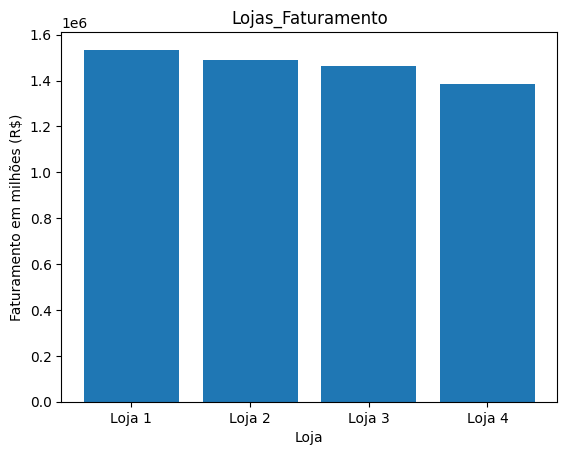

In [13]:
import matplotlib.pyplot as plt

plt.bar(faturamento_lojas.keys(), faturamento_lojas.values())

plt.title('Lojas_Faturamento')
plt.xlabel('Loja')
plt.ylabel('Faturamento em milhões (R$)')


plt.show()

# Interpretação do Gráfico

O gráfico de faturamento por loja mostra que a Loja 1 apresenta o maior volume de vendas, com aproximadamente 1.53 milhão em faturamento total. Em seguida aparecem a Loja 2 e a Loja 3, com valores relativamente próximos entre si, cerca de 1,48 milhão e 1,46 milhão, respectivamente.

A Loja 4 apresenta o menor faturamento, com aproximadamente 1,38 milhão, indicando um desempenho inferior em comparação às demais lojas.

Apesar dessa diferença, o faturamento entre as lojas não apresenta uma disparidade extremamente grande, sugerindo que todas possuem um volume de vendas relativamente semelhante.   Portanto, é necessário analisar outras métricas para um

# 2. Vendas por Categoria

In [43]:
categorias_total = {}

for nome_loja, dados in lojas.items():
    contagem = dados["Categoria do Produto"].value_counts()

    for categoria, quantidade in contagem.items():
        if categoria in categorias_total:
            categorias_total[categoria] += quantidade
        else:
            categorias_total[categoria] = quantidade

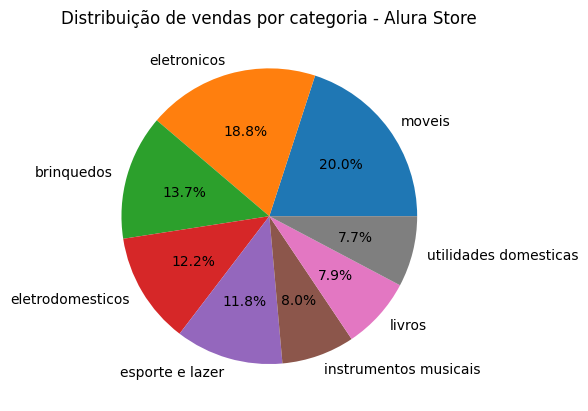

In [44]:
plt.pie(categorias_total.values(),
        labels=categorias_total.keys(),
        autopct='%1.1f%%')

plt.title("Distribuição de vendas por categoria - Alura Store")

plt.show()


# Interpretação gráfico

O gráfico de distribuição de vendas por categoria mostra que as categorias móveis e eletrônicos concentram a maior parte das vendas da Alura Store, representando aproximadamente 20% e 18,8% do total, respectivamente.

De forma geral, observa-se que as vendas estão relativamente distribuídas entre diversas categorias, embora móveis e eletrônicos sejam os principais responsáveis pelo volume de vendas da empresa.


# 3. Média de Avaliação das Lojas


In [46]:
avaliacao_media_lojas = {}

for nome_loja, dados in lojas.items():
    avaliacao_media_lojas[nome_loja] = dados["Avaliação da compra"].mean()

for nome_loja, avaliacao in avaliacao_media_lojas.items():
    print(f"{nome_loja}: {avaliacao:.2f}")

Loja 1: 3.98
Loja 2: 4.04
Loja 3: 4.05
Loja 4: 4.00


# Conclusão

A análise da média de avaliação das lojas mostra que todas apresentam avaliações relativamente altas, próximas da nota 4, indicando um bom nível geral de satisfação dos clientes.

A Loja 3 apresenta a maior média de avaliação (4.05), seguida pela Loja 2 (4.04). Já a Loja 4 apresenta média de 4.00, enquanto a Loja 1 possui a menor média entre as quatro lojas (3.98).

Apesar dessas pequenas diferenças, observa-se que a variação entre as lojas é bastante pequena, o que sugere que a satisfação dos clientes é relativamente consistente entre todas as unidades. Dessa forma, a métrica de avaliação, isoladamente, não indica uma diferença significativa de desempenho entre as lojas.

# 4. Produtos Mais e Menos Vendidos

In [48]:
## Mais vendidos
for nome_loja, dados in lojas.items():
    print(f"\nProdutos mais vendidos - {nome_loja}")
    print(dados["Produto"].value_counts().head()) ## head mostra os 5 mais vendidos

## Menos vendidos
for nome_loja, dados in lojas.items():
    print(f"\nProdutos menos vendidos - {nome_loja}")
    print(dados["Produto"].value_counts().tail()) ## tail mostra os últimos da lista (os que vendem menos)



Produtos mais vendidos - Loja 1
Produto
Micro-ondas           60
TV Led UHD 4K         60
Guarda roupas         60
Secadora de roupas    58
Cômoda                56
Name: count, dtype: int64

Produtos mais vendidos - Loja 2
Produto
Iniciando em programação    65
Micro-ondas                 62
Bateria                     61
Violão                      58
Pandeiro                    58
Name: count, dtype: int64

Produtos mais vendidos - Loja 3
Produto
Kit banquetas      57
Mesa de jantar     56
Cama king          56
Jogo de panelas    55
Cômoda             55
Name: count, dtype: int64

Produtos mais vendidos - Loja 4
Produto
Cama box                    62
Faqueiro                    59
Dashboards com Power BI     56
Cama king                   56
Carrinho controle remoto    55
Name: count, dtype: int64

Produtos menos vendidos - Loja 1
Produto
Ciência de dados com python    39
Pandeiro                       36
Panela de pressão              35
Headset                        33
Celular A

# Conclusão

A análise dos produtos mais e menos vendidos nas quatro lojas mostra que existe uma predominância de itens relacionados a móveis, eletrodomésticos e utilidades domésticas entre os produtos com maior volume de vendas. Produtos como micro-ondas, guarda-roupas, camas e mesas de jantar aparecem entre os mais vendidos em diferentes lojas, indicando uma demanda consistente por esses tipos de produtos na Alura Store.

Por outro lado, os produtos com menor volume de vendas apresentam quantidades relativamente próximas entre si, variando aproximadamente entre 32 e 39 vendas, o que sugere que não existem itens com desempenho extremamente baixo. Entre os menos vendidos aparecem produtos de diferentes categorias, como instrumentos musicais, eletrônicos e livros, indicando que a menor frequência de vendas não está concentrada em apenas um tipo de produto específico.

Também é possível observar que alguns produtos aparecem tanto entre os mais vendidos quanto entre os menos vendidos em diferentes lojas, o que pode indicar variações de preferência entre os clientes de cada região. De forma geral, a análise mostra que as lojas apresentam um portfólio relativamente diversificado e equilibrado, sem dependência extrema de um único produto ou presença de itens com vendas extremamente baixas.

# 5. Frete Médio por Loja

In [49]:
frete_medio_lojas = {}

for nome_loja, dados in lojas.items():
    frete_medio_lojas[nome_loja] = dados["Frete"].mean()

for nome_loja, frete in frete_medio_lojas.items():
    print(f"{nome_loja}: R$ {frete:.2f}")

Loja 1: R$ 34.69
Loja 2: R$ 33.62
Loja 3: R$ 33.07
Loja 4: R$ 31.28


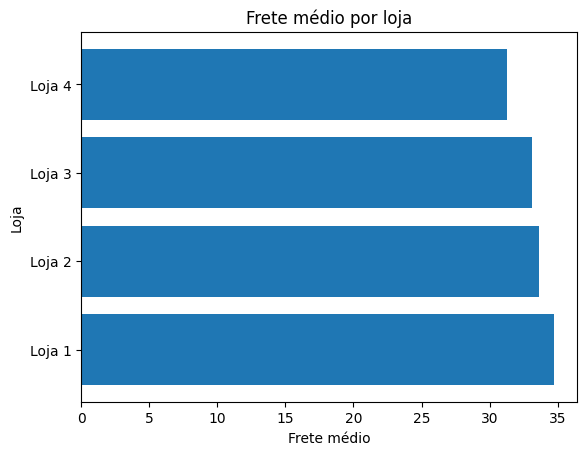

In [50]:
plt.barh(list(frete_medio_lojas.keys()), list(frete_medio_lojas.values()))

plt.title('Frete médio por loja')
plt.xlabel('Frete médio')
plt.ylabel('Loja')

plt.show()

# Interpretação Gráfico

O gráfico de frete médio por loja mostra que os valores de frete apresentam pequenas variações entre as lojas analisadas. A Loja 1 apresenta o maior frete médio, com aproximadamente 34,69 reais, seguida pela Loja 2, com cerca de 33,62 reais, e pela Loja 3, com aproximadamente 33,07 reais.

A Loja 4 apresenta o menor frete médio, com cerca de R$ 31,28, indicando um custo médio de entrega ligeiramente menor em comparação às demais lojas.

Apesar dessa diferença, observa-se que os valores de frete médio entre as lojas são relativamente próximos, o que sugere que os custos logísticos são semelhantes entre as unidades da Alura Store.

## Qual loja deve ser vendida?

A partir das análises realizadas sobre os dados das quatro lojas da rede Alura Store, foi possível avaliar diferentes métricas importantes para entender o desempenho de cada unidade. Entre os principais indicadores analisados estão faturamento total, distribuição de vendas por categoria, média de avaliação dos clientes, produtos mais e menos vendidos e frete médio por loja.

**A respeito do Faturamento** observou-se que a Loja 4 apresenta o menor volume de vendas, com aproximadamente R$ 1,38 milhão, enquanto as demais lojas apresentam valores ligeiramente superiores. Esse resultado indica que a Loja 4 possui um desempenho inferior em termos de geração de receita quando comparada às outras unidades.

**Distribuição de vendas por categoria** mostrou que as vendas estão relativamente bem distribuídas entre diferentes tipos de produtos, com destaque para as categorias móveis e eletrônicos, que representam a maior parcela das vendas da empresa. Esse padrão se repete entre as lojas, indicando um comportamento de consumo semelhante entre os clientes.

A média de **avaliação das lojas** apresentou valores muito próximos entre si, todos próximos da nota 4, o que sugere um bom nível geral de satisfação e pouca variação significativa entre as unidades.

**A análise dos produtos mais e menos vendidos** mostrou que as lojas possuem um portfólio relativamente diversificado e equilibrado, sem forte dependência de um único produto ou presença de itens com vendas extremamente baixas.

Por fim, na análise do **frete médio por loja**, observou-se que a Loja 4 apresenta o menor valor médio de frete, indicando uma logística ligeiramente mais eficiente. Entretanto, essa vantagem não se reflete em um maior faturamento quando comparada às demais lojas.

Considerando o conjunto das métricas analisadas, conclui-se que a Loja 4 apresenta o menor desempenho geral em termos de faturamento, enquanto as demais métricas mostram resultados relativamente equilibrados entre as unidades. Dessa forma, a recomendação é que o **Senhor João** considere vender a Loja 4, pois ela apresenta o menor retorno financeiro entre as lojas analisadas, mantendo as demais unidades que demonstram melhor desempenho em vendas.

